In [ ]:
# Cell 1: Install and import all required libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 2: Download the PlantVillage dataset

import kagglehub

# Download the dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded to: /kaggle/input/plantvillage-dataset


In [ ]:
# Cell 3 Fixed: Find the exact dataset path

import os

base_path = "/kaggle/input/plantvillage-dataset"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")

plantvillage-dataset/
  plantvillage dataset/
    segmented/
    grayscale/
    color/


In [ ]:
# Cell 4: Verify dataset classes

import os

dataset_path = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

classes = sorted(os.listdir(dataset_path))
print(f"Total classes: {len(classes)}")
for i, cls in enumerate(classes):
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"  {i+1:2d}. {cls} — {count} images")

Total classes: 38
   1. Apple___Apple_scab — 630 images
   2. Apple___Black_rot — 621 images
   3. Apple___Cedar_apple_rust — 275 images
   4. Apple___healthy — 1645 images
   5. Blueberry___healthy — 1502 images
   6. Cherry_(including_sour)___Powdery_mildew — 1052 images
   7. Cherry_(including_sour)___healthy — 854 images
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 513 images
   9. Corn_(maize)___Common_rust_ — 1192 images
  10. Corn_(maize)___Northern_Leaf_Blight — 985 images
  11. Corn_(maize)___healthy — 1162 images
  12. Grape___Black_rot — 1180 images
  13. Grape___Esca_(Black_Measles) — 1383 images
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 1076 images
  15. Grape___healthy — 423 images
  16. Orange___Haunglongbing_(Citrus_greening) — 5507 images
  17. Peach___Bacterial_spot — 2297 images
  18. Peach___healthy — 360 images
  19. Pepper,_bell___Bacterial_spot — 997 images
  20. Pepper,_bell___healthy — 1478 images
  21. Potato___Early_blight — 1000 images

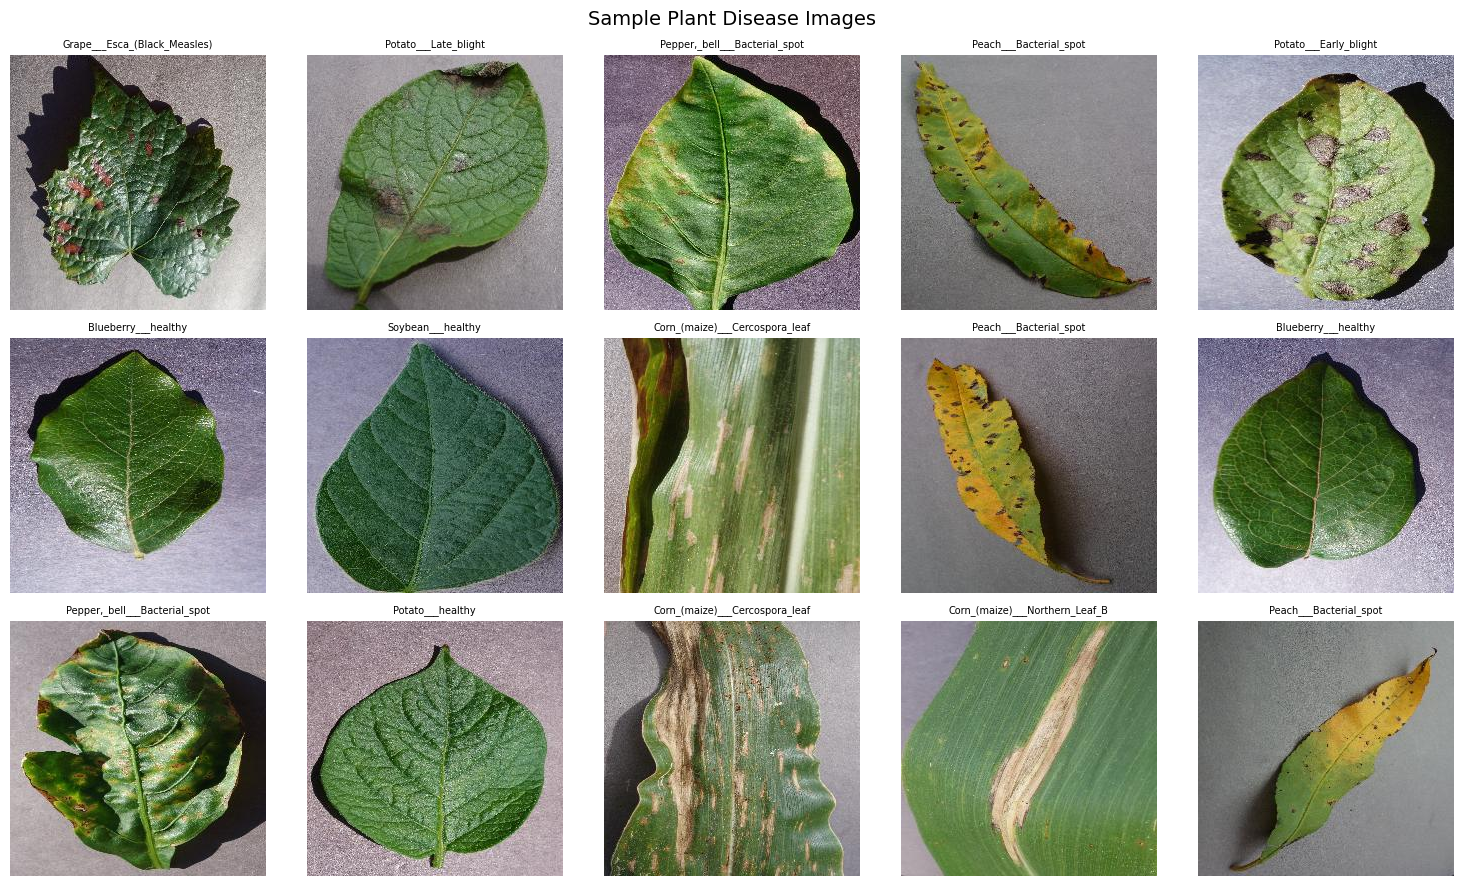

In [ ]:
# Cell 5: Visualize sample images from dataset

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    cls = random.choice(classes)
    img_file = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    img_path = os.path.join(dataset_path, cls, img_file)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls[:30], fontsize=7)
    ax.axis('off')

plt.suptitle("Sample Plant Disease Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Prepare data generators (train, validation, test split)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Training data: augmentation to make model more robust
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data: only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = len(train_generator.class_indices)
print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Number of classes:  {NUM_CLASSES}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Training samples:   43456
Validation samples: 10849
Number of classes:  38


In [ ]:
# Cell 7: Build a strong CNN model using Transfer Learning (EfficientNetB3)
# EfficientNetB3 is pretrained on ImageNet — gives much better accuracy than building from scratch

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models

base_model = EfficientNetB3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model first (we train only our custom layers initially)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,717,717 (44.70 MB)

 Trainable params: 931,110 (3.55 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
# Cell 8: Train Phase 1 — train only top layers (base model frozen)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print("Phase 1 training complete!")

Epoch 1/15
  98/1358 ━━━━━━━━━━━━━━━━━━━━ 12:31 597ms/step - accuracy: 0.0829 - loss: 3.9165

KeyboardInterrupt: 